In [1]:
from pyrokinetics import Pyro, PyroScan
import os
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt

KeyboardInterrupt: 

In [2]:
# Replace with path to your Gyrokinetic Simulations
GYRO_DIR  = Path("/mnt/data/Gyrokinetic_Simulations/")

In [3]:
cases = ["M1_A1_NE","R3","R4","S1_3"]
projects = ["scan_q","scan_shat","scan_beta"]
# cases = ["R3","R4"]
# projects = ["scan_beta"]

In [4]:
project_dict ={}
for project in projects:
    case_dict = {}
    for case in cases:
        print(f"Project: {project}, Case: {case}")
        json_path = Path(GYRO_DIR / Path(f"GS2/Runs/{project}/{case}/parameter_scan_GS2/pyroscan.json"))
        net_cdf_path = Path(GYRO_DIR / Path(f"GS2/Runs/{project}/{case}/parameter_scan_GS2/pyroscan.nc"))
        try:
            gs2_pyoscan = PyroScan(pyroscan_json=json_path, load_base_pyro=True)
            try:
                gs2_pyoscan.load_gk_output(netcdf_file=net_cdf_path)
                case_dict[case] = gs2_pyoscan
            except Exception as e:
                print(f"Error loading gk output for {project}/{case}: {e}")
                try:
                    gs2_pyoscan.load_gk_output()
                    gs2_pyoscan.gk_output.to_netcdf(net_cdf_path)
                    case_dict[case] = gs2_pyoscan
                except Exception as e:
                    print(f"Error loading gk output without netcdf for {project}/{case}: {e}")
        except Exception as e:
            print(f"Error loading pyroscan for {project}/{case}: {e}")
            continue
    project_dict[project] = case_dict

Project: scan_q, Case: M1_A1_NE


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/pyrokinetics/src/pyrokinetics/normalisation.py:943: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0000'. 
  warnings.warn(


Project: scan_q, Case: R3
Project: scan_q, Case: R4
Project: scan_q, Case: S1_3


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/pyrokinetics/src/pyrokinetics/pyro.py:1785: UserWarning: Explicitly set value of beta (0.09 beta_ref_ee_B0_pyroscan_base0003) is inconsistent with value from physical reference values (0.09609377161346086 beta_ref_ee_B0_pyroscan_base0003)
  warnings.warn(
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/pyrokinetics/src/pyrokinetics/normalisation.py:943: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0003'. 
  warnings.warn(


Project: scan_shat, Case: M1_A1_NE


...

Project: scan_shat, Case: R3
Project: scan_shat, Case: R4
Error loading gk output for scan_shat/R4: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/GS2/Runs/scan_shat/R4/parameter_scan_GS2/pyroscan.nc'
Error loading gk output without netcdf for scan_shat/R4: Unable to load any gk_output files in this scan
Project: scan_shat, Case: S1_3


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/pyrokinetics/src/pyrokinetics/pyroscan.py:821: UserWarning: Unable to load gk_output for /mnt/data/Gyrokinetic_Simulations/GS2/Runs/scan_shat/R4/parameter_scan_GS2/ky0.100_shat-0.250/gs2.in [ValueError: File /mnt/data/Gyrokinetic_Simulations/GS2/Runs/scan_shat/R4/parameter_scan_GS2/ky0.100_shat-0.250/gs2.out.nc not found.]
  warnings.warn(
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/pyrokinetics/src/pyrokinetics/pyroscan.py:821: UserWarning: Unable to load gk_output for /mnt/data/Gyrokinetic_Simulations/GS2/Runs/scan_shat/R4/parameter_scan_GS2/ky0.100_shat-0.056/gs2.in [ValueError: File /mnt/data/Gyrokinetic_Simulations/GS2/Runs/scan_shat/R4/parameter_scan_GS2/ky0.100_shat-0.056/gs2.out.nc not found.]
  warnings.warn(
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/pyrokinetics/src/pyrokinetics/pyroscan.py:821: UserWarning: Unable to load gk_output for /mnt/data/Gyrokinetic_Simu

Project: scan_beta, Case: M1_A1_NE


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/pyrokinetics/src/pyrokinetics/normalisation.py:943: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0008'. 
  warnings.warn(


Project: scan_beta, Case: R3
Project: scan_beta, Case: R4
Project: scan_beta, Case: S1_3
Error loading pyroscan for scan_beta/S1_3: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/GS2/Runs/scan_beta/S1_3/parameter_scan_GS2/pyroscan.json'


In [5]:
tglf_versions = ["TGLF_sat2","tglf_v3","tglf_v5_nm10","tglf_v5_nb6"]
name_dict = {
    "TGLF_sat2":"Default",
    "tglf_v3": "Fixed.W",
    "tglf_v5_nm10": "Expanded.S",
    "tglf_v5_nb6": "A.Naj",

}
tglf_project_dict ={}
for project in projects:
    case_dict = {}
    for case in cases:
        version_dict = {}
        for version in tglf_versions:
            print(f"Project: {project}, Case: {case}")
            json_path = Path(GYRO_DIR / Path(f"TGLF/Runs/{project}/{case}/parameter_scan_{version}/pyroscan.json"))
            net_cdf_path = Path(GYRO_DIR / Path(f"TGLF/Runs/{project}/{case}/parameter_scan_{version}/pyroscan.nc"))
            try:
                tglf_pyoscan = PyroScan(pyroscan_json=json_path, load_base_pyro=True)
                try:
                    tglf_pyoscan.load_gk_output(netcdf_file=net_cdf_path)
                    version_dict[name_dict[version]] = tglf_pyoscan
                except Exception as e:
                    print(f"Error loading gk output for {project}/{case}/{version}: {e}")
                    # try:
                    #     tglf_pyoscan.load_gk_output()
                    #     tglf_pyoscan.gk_output.to_netcdf(net_cdf_path)
                    #     version_dict[version] = tglf_pyoscan
                    # except Exception as e:
                    #     print(f"Error loading gk output without netcdf for {project}/{case}/{version}: {e}")
            except Exception as e:
                print(f"Error loading pyroscan for {project}/{case}/{version}: {e}")
                continue
        case_dict[case] = version_dict
    tglf_project_dict[project] = case_dict

Project: scan_q, Case: M1_A1_NE


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/pyrokinetics/src/pyrokinetics/normalisation.py:943: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0011'. 
  warnings.warn(


Project: scan_q, Case: M1_A1_NE


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/pyrokinetics/src/pyrokinetics/normalisation.py:943: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0012'. 
  warnings.warn(


Project: scan_q, Case: M1_A1_NE


...

Project: scan_beta, Case: M1_A1_NE


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/pyrokinetics/src/pyrokinetics/normalisation.py:943: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0043'. 
  warnings.warn(


Project: scan_beta, Case: M1_A1_NE


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/pyrokinetics/src/pyrokinetics/normalisation.py:943: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0044'. 
  warnings.warn(


Project: scan_beta, Case: R3
Project: scan_beta, Case: R3
Project: scan_beta, Case: R3
Project: scan_beta, Case: R3
Project: scan_beta, Case: R4
Project: scan_beta, Case: R4
Project: scan_beta, Case: R4
Project: scan_beta, Case: R4
Project: scan_beta, Case: S1_3
Error loading pyroscan for scan_beta/S1_3/TGLF_sat2: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/TGLF/Runs/scan_beta/S1_3/parameter_scan_TGLF_sat2/pyroscan.json'
Project: scan_beta, Case: S1_3
Error loading pyroscan for scan_beta/S1_3/tglf_v3: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/TGLF/Runs/scan_beta/S1_3/parameter_scan_tglf_v3/pyroscan.json'
Project: scan_beta, Case: S1_3
Error loading pyroscan for scan_beta/S1_3/tglf_v5_nm10: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/TGLF/Runs/scan_beta/S1_3/parameter_scan_tglf_v5_nm10/pyroscan.json'
Project: scan_beta, Case: S1_3
Error loading pyroscan for scan_beta/S1_3/tglf_v5_nb6: [Errno 2] No such

In [35]:
gftm_versions = [
    "gftm_width_0.8",
    "gftm_width_1.3",
    "gftm_width_1.74",
]

name_dict = {
    "gftm_width_0.8": "Width 0.8",
    "gftm_width_1.3": "Width 1.3",
    "gftm_width_1.74": "Width 1.74",
}

gftm_project_dict = {}

for project in projects:
    case_dict = {}

    for case in cases:
        version_dict = {}

        for version in gftm_versions:
            print(f"Project: {project}, Case: {case}, Version: {version}")

            json_path = (
                GYRO_DIR
                / "GFTM"
                / "Runs"
                / project
                / case
                / f"parameter_scan_{version}"
                / "pyroscan.json"
            )

            netcdf_path = (
                GYRO_DIR
                / "GFTM"
                / "Runs"
                / project
                / case
                / f"parameter_scan_{version}"
                / "pyroscan.nc"
            )

            try:
                gftm_pyroscan = PyroScan(
                    pyroscan_json=json_path,
                    load_base_pyro=True,
                )

                try:
                    gftm_pyroscan.load_gk_output(
                        netcdf_file=netcdf_path
                    )

                except Exception as netcdf_error:
                    print(
                        f"Could not load NetCDF for "
                        f"{project}/{case}/{version}: "
                        f"{netcdf_error}"
                    )

                    try:
                        gftm_pyroscan.load_gk_output()
                        gftm_pyroscan.gk_output.to_netcdf(netcdf_path)

                    except Exception as output_error:
                        print(
                            f"Could not load GK output for "
                            f"{project}/{case}/{version}: "
                            f"{output_error}"
                        )
                        continue

                # Always use the same key, regardless of loading path
                version_dict[version] = gftm_pyroscan

            except Exception as pyroscan_error:
                print(
                    f"Could not load PyroScan for "
                    f"{project}/{case}/{version}: "
                    f"{pyroscan_error}"
                )
                continue

        case_dict[case] = version_dict

    gftm_project_dict[project] = case_dict

Project: scan_q, Case: M1_A1_NE, Version: gftm_width_0.8


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/pyrokinetics/src/pyrokinetics/normalisation.py:943: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0089'. 
  warnings.warn(


Project: scan_q, Case: M1_A1_NE, Version: gftm_width_1.3


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/pyrokinetics/src/pyrokinetics/normalisation.py:943: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0090'. 
  warnings.warn(


Project: scan_q, Case: M1_A1_NE, Version: gftm_width_1.74


...

/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/pyrokinetics/src/pyrokinetics/normalisation.py:943: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0122'. 
  warnings.warn(


Project: scan_beta, Case: S1_3, Version: gftm_width_1.3


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/pyrokinetics/src/pyrokinetics/normalisation.py:943: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0123'. 
  warnings.warn(


Project: scan_beta, Case: S1_3, Version: gftm_width_1.74


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/pyrokinetics/src/pyrokinetics/normalisation.py:943: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0124'. 
  warnings.warn(


In [9]:
tglf_versions = ["Default","V3","FW","AN"]
tglf_versions = [key for key in tglf_project_dict[project][case].keys() if key != "reference"]
gftm_versions = [key for key in gftm_project_dict[project][case].keys() if key != "reference"]

In [8]:
# GYRO_DATA = Path("/mnt/data/Gyrokinetic_Simulations")
# models_path = "/home/Felix/Documents/Physics_Work/Project_Codes/GP-MODELS/0.0.3/"  # This is using the 3000 data point model as opposed to the 100000 data point model for testing purposes


# models = [
#     "growth_rate",
#     "mode_frequency_log",
#     "kperp2_phi_log",
#     "kperp2_apa_log",
#     "kperp2_bpar_log",
#     "totIonFlux_log",
#     "totElecFlux_log",
#     "totPartFlux_log",
#     "apa_phi_log",
#     "bpar_phi_log",
# ]

# from pyrokinetics.diagnostics.gs2_gp import gs2_gp

In [9]:
# project = "scan_q"
# case = "S1"

# Gaussian_Model =gs2_gp(pyro=project_dict[project][case], models_path=models_path, models=models)

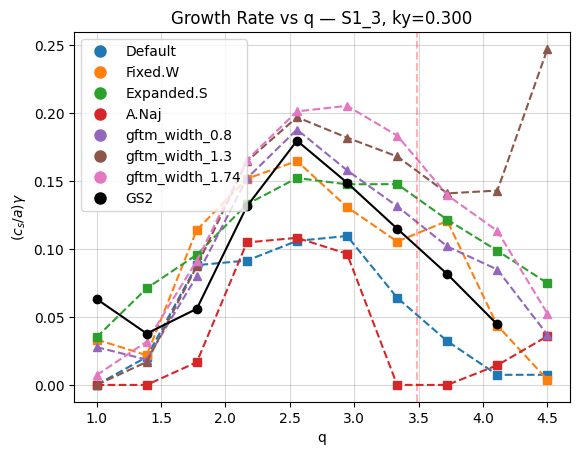

In [13]:

# Plot Q scan
project = "scan_q"
case = "S1_3"
ky = 0.3
reference_q = 3.49


for tglf in tglf_versions:
    (tglf_project_dict[project][case][tglf]
        .gk_output["growth_rate"]
        .sel(ky=ky, method="nearest")
        .sel(mode=0)
        .plot(label=tglf, marker="s", linestyle="--"))

# GFTM/GFS: solid lines with square markers
for gftm in gftm_versions:
    growth_rate = (
        gftm_project_dict[project][case][gftm]
        .gk_output["growth_rate"]
        .sel(ky=ky, method="nearest")
        .sel(mode=0)
    )

    growth_rate.plot(
        label=f"{gftm}",
        marker="^",
        linestyle="--",
        markersize=6,
    )

gs2_growth_rate = (project_dict[project][case]
    .gk_output["growth_rate"]
    .sel(ky=ky, method="nearest"))
gs2_growth_rate_tolerance = (project_dict[project][case]
    .gk_output["growth_rate_tolerance"]
    .sel(ky=ky, method="nearest"))
gs2_growth_rate = gs2_growth_rate.where(gs2_growth_rate_tolerance < 0.3)

# Gaussian_Model = gs2_gp(pyro=project_dict[project][case],
#                        models_path=models_path, models=models)
# gp = (Gaussian_Model.gk_output["growth_rate"]
#     .sel(output="value")
#     .sel(ky=ky, method="nearest"))
# gp_max = (Gaussian_Model.gk_output["growth_rate"]
#     .sel(output="max_value")
#     .sel(ky=ky, method="nearest"))
# gp_min = (Gaussian_Model.gk_output["growth_rate"]
#     .sel(output="min_value")
#     .sel(ky=ky, method="nearest"))

# gp.plot(label="GS2-GP", marker="o", linestyle="--")
# plt.fill_between(gp["q"].values, gp_min.values, gp_max.values, color="blue", alpha=0.2, label="GS2-GP Uncertainty")
gs2_growth_rate.plot(label="GS2", color="black", marker="o")

ky_actual = float(
    project_dict[project][case].gk_output["growth_rate"]
    .sel(ky=ky, method="nearest")
    .ky
)
plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")

plt.title(f"Growth Rate vs q — {case}, ky={ky_actual:.3f}")
#plt.title("")
plt.xlabel("q")
plt.ylabel(r"$(c_s/a) \gamma$")
plt.grid(alpha=0.3, color='grey')
from matplotlib.lines import Line2D

handles, labels = plt.gca().get_legend_handles_labels()
dot_handles = [
    Line2D([], [], color=h.get_color(), marker="o", linestyle="none", markersize=8)
    for h in handles
]
plt.legend(dot_handles, labels)
path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
#plt.savefig(f"{path}/Growth Rate vs q — {case}, ky={ky_actual:.3f}.png", dpi=300)



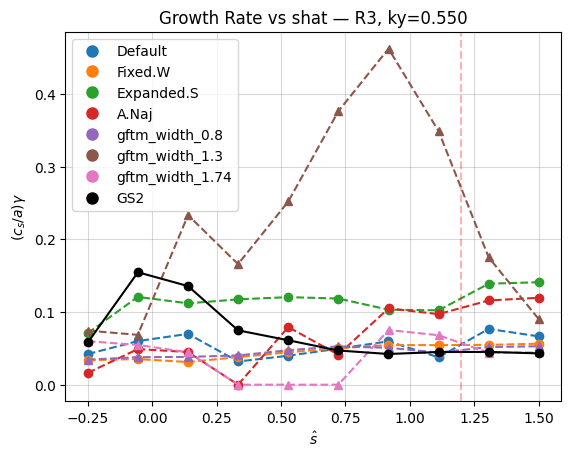

In [20]:
from matplotlib import pyplot as plt
# Plot shat scan
project = "scan_shat"
case = "R3"
ky = 0.6
reference_q = 1.2


for tglf in tglf_versions:
    tglf_project_dict[project][case][tglf].gk_output["growth_rate"].sel(ky =ky,method = "nearest").sel(mode =0).plot(label = tglf,marker = "o",linestyle = "--")

# GFTM/GFS: solid lines with square markers
for gftm in gftm_versions:
    growth_rate = (
        gftm_project_dict[project][case][gftm]
        .gk_output["growth_rate"]
        .sel(ky=ky, method="nearest")
        .sel(mode=0)
    )

    growth_rate.plot(
        label=f"{gftm}",
        marker="^",
        linestyle="--",
        markersize=6,
    )


gs2_growth_rate = project_dict[project][case].gk_output["growth_rate"].sel(ky =ky,method = "nearest")
gs2_growth_rate_tolerance = project_dict[project][case].gk_output["growth_rate_tolerance"].sel(ky =ky,method = "nearest")
gs2_growth_rate = gs2_growth_rate.where(gs2_growth_rate_tolerance<0.3)
gs2_growth_rate.plot(label = "GS2", color = "black",marker = "o")
ky_actual = float(
    project_dict[project][case].gk_output["growth_rate"]
    .sel(ky=ky, method="nearest")
    .ky
)

plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")


plt.title(f"Growth Rate vs shat — {case}, ky={ky_actual:.3f}")
plt.xlabel(r"$\hat{s}$")
plt.ylabel(r"$(c_s/a) \gamma$")
plt.grid(alpha=0.3, color='grey')
from matplotlib.lines import Line2D

handles, labels = plt.gca().get_legend_handles_labels()
dot_handles = [
    Line2D([], [], color=h.get_color(), marker="o", linestyle="none", markersize=8)
    for h in handles
]
plt.legend(dot_handles, labels)
path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
#plt.savefig(f"{path}/Growth Rate vs shat — {case}, ky={ky_actual:.3f}.png", dpi=300)



In [21]:
tglf_project_dict

{'scan_beta': {'M1_A1_NE': {'Default': <pyrokinetics.pyroscan.PyroScan at 0x7f809fb68d70>,
   'Fixed.W': <pyrokinetics.pyroscan.PyroScan at 0x7f808d2ff4d0>,
   'Expanded.S': <pyrokinetics.pyroscan.PyroScan at 0x7f80a8e335c0>,
   'A.Naj': <pyrokinetics.pyroscan.PyroScan at 0x7f8081ba4500>},
  'R3': {'Default': <pyrokinetics.pyroscan.PyroScan at 0x7f807cb335c0>,
   'Fixed.W': <pyrokinetics.pyroscan.PyroScan at 0x7f80783cc6e0>,
   'Expanded.S': <pyrokinetics.pyroscan.PyroScan at 0x7f8073f9d7c0>,
   'A.Naj': <pyrokinetics.pyroscan.PyroScan at 0x7f806f8da8a0>},
  'R4': {'Default': <pyrokinetics.pyroscan.PyroScan at 0x7f806abf3980>,
   'Fixed.W': <pyrokinetics.pyroscan.PyroScan at 0x7f8065b44aa0>,
   'Expanded.S': <pyrokinetics.pyroscan.PyroScan at 0x7f8060e69b80>,
   'A.Naj': <pyrokinetics.pyroscan.PyroScan at 0x7f805c186c60>},
  'S1_3': {}}}

In [70]:
tglf_versions = [key for key in tglf_project_dict[project][case].keys() if key != "reference"]
gftm_versions = [key for key in gftm_project_dict[project][case].keys() if key != "reference"]
#gftm_versions = ["Width 1.74"]

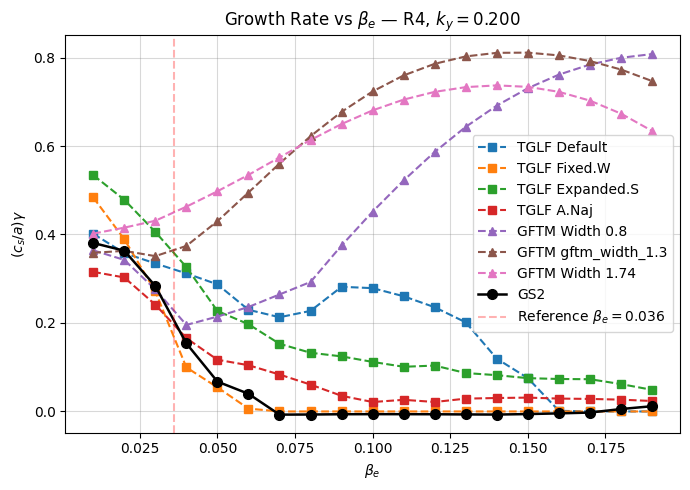

In [73]:
import os

from matplotlib import pyplot as plt


# Plot beta scan
project = "scan_beta"
case = "R4"
ky = 0.2
reference_beta = 0.036

fig, ax = plt.subplots(figsize=(7, 5))


# TGLF: dashed lines with circular markers
for tglf in tglf_versions:
    growth_rate = (
        tglf_project_dict[project][case][tglf]
        .gk_output["growth_rate"]
        .sel(ky=ky, method="nearest")
        .sel(mode=0)
    )

    growth_rate.plot(
        ax=ax,
        label=f"TGLF {tglf}",
        marker="s",
        linestyle="--",
        markersize=6,
    )


# GFTM/GFS: solid lines with square markers
for gftm in gftm_versions:
    growth_rate = (
        gftm_project_dict[project][case][gftm]
        .gk_output["growth_rate"]
        .sel(ky=ky, method="nearest")
        .sel(mode=0)
    )

    growth_rate.plot(
        ax=ax,
        label=f"GFTM {gftm}",
        marker="^",
        linestyle="--",
        markersize=6,
    )


# GS2: dashed black line with triangular markers
gs2_growth_rate = (
    project_dict[project][case]
    .gk_output["growth_rate"]
    .sel(ky=ky, method="nearest")
)

gs2_growth_rate_tolerance = (
    project_dict[project][case]
    .gk_output["growth_rate_tolerance"]
    .sel(ky=ky, method="nearest")
)

# Optionally remove GS2 points with a large tolerance:
# gs2_growth_rate = gs2_growth_rate.where(
#     gs2_growth_rate_tolerance < 0.1
# )

gs2_growth_rate.plot(
    ax=ax,
    label="GS2",
    color="black",
    marker="o",
    linestyle="-",
    markersize=7,
    linewidth=1.8,
)


# Actual ky selected from the data
ky_actual = float(
    project_dict[project][case]
    .gk_output["growth_rate"]
    .sel(ky=ky, method="nearest")
    .ky
)


# Reference beta
ax.axvline(
    x=reference_beta,
    color="red",
    alpha=0.3,
    linestyle="--",
    label=rf"Reference $\beta_e={reference_beta}$",
)


ax.set_title(
    rf"Growth Rate vs $\beta_e$ — {case}, $k_y={ky_actual:.3f}$"
)
ax.set_xlabel(r"$\beta_e$")
ax.set_ylabel(r"$(c_s/a)\gamma$")
ax.grid(alpha=0.3, color="grey")
ax.legend()


fig.tight_layout()

path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)

# fig.savefig(
#     f"{path}/Growth Rate vs beta — {case}, ky={ky_actual:.3f}.png",
#     dpi=300,
#     bbox_inches="tight",
# )

plt.show()

In [ ]:
tglf_project_dict["scan_beta"]["R3"]["emS"].gk_output["growth_rate"].isel(ky=4)

In [ ]:
#tglf_versions = ["Default","A.Naj"]

KeyError: 'gftm_width_0.8'

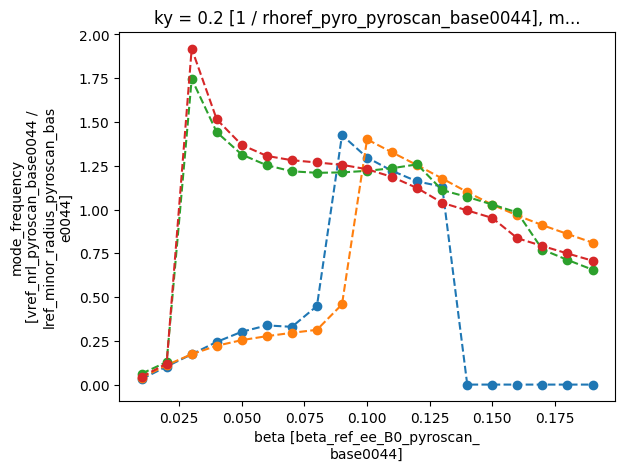

In [21]:
from matplotlib import pyplot as plt
# Plot shat scan
project = "scan_beta"
case = "M1_A1_NE"
ky = 0.2
reference_q = 0.036


for tglf in tglf_versions:
    tglf_project_dict[project][case][tglf].gk_output["mode_frequency"].sel(ky =ky,method = "nearest").sel(mode =0).plot(label = tglf,marker = "o",linestyle = "--")

for gftm in gftm_versions:
    gftm_project_dict[project][case][gftm].gk_output["mode_frequency"].sel(ky =ky,method = "nearest").sel(mode =0).plot(label = gftm,marker = "o",linestyle = "--")




gs2_mode_frequency = project_dict[project][case].gk_output["mode_frequency"].sel(ky =ky,method = "nearest")
gs2_mode_frequency_tolerance = project_dict[project][case].gk_output["growth_rate_tolerance"].sel(ky =ky,method = "nearest")
#gs2_mode_frequency = gs2_mode_frequency.where(gs2_mode_frequency_tolerance<0.1)
gs2_mode_frequency.plot(label = "GS2", color = "black",marker = "o")
ky_actual = float(
    project_dict[project][case].gk_output["mode_frequency"]
    .sel(ky=ky, method="nearest")
    .ky
)

plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")

plt.title(f"mode_frequency vs beta — {case}, ky={ky_actual:.3f}")
plt.xlabel(r"$\beta_e$")
plt.ylabel(r"$(c_s/a) \omega$")
plt.grid(alpha=0.3, color='grey')
plt.yscale("log")
from matplotlib.lines import Line2D

handles, labels = plt.gca().get_legend_handles_labels()
dot_handles = [
    Line2D([], [], color=h.get_color(), marker="o", linestyle="none", markersize=8)
    for h in handles
]
plt.legend(dot_handles, labels)
path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
#plt.savefig(f"{path}/mode_frequency vs beta — {case}, ky={ky_actual:.3f}.png", dpi=300)

In [22]:
from pathlib import Path

import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np


_SCAN_LABELS = {
    "beta": r"$\beta_e$",
    "q": r"$q$",
    "shat": r"$\hat{s}$",
    "ky": r"$k_y$",
}

_FIELD_SYM = {
    "growth_rate": r"\gamma",
    "mode_frequency": r"\omega",
}


def _normalise_model_outputs(outputs, model_name):
    """
    Convert model outputs into an ordered list of (label, output) pairs.

    Parameters
    ----------
    outputs : mapping, sequence, single output, or None
        Model outputs to normalise.

    model_name : str
        Name prepended to output labels, such as ``"TGLF"`` or ``"GFTM"``.

    Returns
    -------
    list of tuple
        A list containing ``(label, output)`` pairs.
    """
    if outputs is None:
        return []

    if hasattr(outputs, "items"):
        return [
            (f"{model_name} {label}", output)
            for label, output in outputs.items()
        ]

    if isinstance(outputs, (list, tuple)):
        return [
            (f"{model_name} {index}", output)
            for index, output in enumerate(outputs)
        ]

    return [(model_name, outputs)]


def _difference_grid(
    gs2_output,
    model_output,
    field,
    metric,
    scan_param,
    mode,
):
    """
    Return (ky, parameter, difference, scan_param) for one model/GS2 pair.

    ``model_output`` may be either a TGLF or GFTM output.
    """
    gr_gs2 = gs2_output[field]
    gr_model = model_output[field]

    if "mode" in gr_model.dims:
        gr_model = gr_model.sel(mode=mode)

    if "mode" in gr_gs2.dims:
        gr_gs2 = gr_gs2.sel(mode=mode)

    if scan_param is None:
        other_dims = [
            dim
            for dim in gr_gs2.dims
            if dim not in {"ky", "mode", "kx"}
        ]

        if len(other_dims) != 1:
            raise ValueError(
                "Could not auto-detect scan_param from GS2 dimensions "
                f"{gr_gs2.dims}. Pass scan_param explicitly."
            )

        scan_param = other_dims[0]

    required_dims = {"ky", scan_param}

    missing_gs2 = required_dims.difference(gr_gs2.dims)
    if missing_gs2:
        raise ValueError(
            f"GS2 field {field!r} is missing dimensions: "
            f"{sorted(missing_gs2)}"
        )

    missing_model = required_dims.difference(gr_model.dims)
    if missing_model:
        raise ValueError(
            f"Model field {field!r} is missing dimensions: "
            f"{sorted(missing_model)}"
        )

    # Select kx=0 if a kx dimension remains.
    if "kx" in gr_gs2.dims:
        gr_gs2 = gr_gs2.sel(kx=0.0, method="nearest")

    if "kx" in gr_model.dims:
        gr_model = gr_model.sel(kx=0.0, method="nearest")

    # Interpolate the model output onto the GS2 grid so that subtraction
    # is well defined. This applies to both TGLF and GFTM.
    gr_model = gr_model.interp(
        ky=gr_gs2["ky"],
        **{scan_param: gr_gs2[scan_param]},
    )

    gr_gs2 = gr_gs2.transpose("ky", scan_param)
    gr_model = gr_model.transpose("ky", scan_param)

    gs2_values = np.asarray(gr_gs2.values)
    model_values = np.asarray(gr_model.values)

    if metric == "absolute":
        difference = model_values - gs2_values

    elif metric == "relative":
        # Avoid warnings and infinities where the GS2 value is zero.
        difference = np.full_like(
            model_values,
            np.nan,
            dtype=np.result_type(model_values, float),
        )

        np.divide(
            model_values - gs2_values,
            np.abs(gs2_values),
            out=difference,
            where=np.abs(gs2_values) > 0.0,
        )

    else:
        raise ValueError(
            "metric must be either 'absolute' or 'relative'"
        )

    return (
        gr_gs2["ky"].data,
        gr_gs2[scan_param].data,
        difference,
        scan_param,
    )


def plot_field_difference(
    gs2_output,
    tglf_outputs=None,
    gftm_outputs=None,
    field="growth_rate",
    metric="absolute",
    scan_param=None,
    mode=0,
    vmax=None,
    vmax_quantile=1.0,
    cmap="seismic",
    axes=None,
    savefig=None,
):
    """
    Plot model-minus-GS2 differences over (ky, scan parameter).

    One panel is produced for every supplied TGLF and GFTM version. Both
    ``tglf_outputs`` and ``gftm_outputs`` accept dictionaries, sequences,
    single outputs, or ``None``.

    All panels use a shared, symmetric colour scale.

    Parameters
    ----------
    gs2_output : PyroScanGKOutput
        GS2 reference output.

    tglf_outputs : mapping, sequence, single output, or None
        TGLF outputs. For example::

            {
                "Default": default_tglf_output,
                "Fixed width": fixed_width_tglf_output,
            }

        This produces panels labelled ``TGLF Default`` and
        ``TGLF Fixed width``.

    gftm_outputs : mapping, sequence, single output, or None
        GFTM outputs, with the same accepted structure as
        ``tglf_outputs``. For example::

            {
                "Default": default_gftm_output,
                "Expanded": expanded_gftm_output,
            }

        This produces panels labelled ``GFTM Default`` and
        ``GFTM Expanded``.

    field : str
        Usually ``"growth_rate"`` or ``"mode_frequency"``.

    metric : {"absolute", "relative"}
        ``"absolute"`` gives::

            model - GS2

        ``"relative"`` gives::

            (model - GS2) / abs(GS2)

    scan_param : str or None
        Name of the scan dimension, such as ``"beta"``, ``"q"``, or
        ``"shat"``. It is inferred from the GS2 dimensions when possible.

    mode : int
        Mode selected from outputs containing a ``mode`` dimension.

    vmax : float or None
        Symmetric colour limit. When omitted, it is derived from all TGLF
        and GFTM difference values.

    vmax_quantile : float
        Quantile of pooled absolute differences used when deriving
        ``vmax``. For example, ``0.98`` clips the largest two percent of
        values from the colour-scale calculation.

    cmap : str
        Matplotlib diverging colour map.

    axes : array-like of matplotlib Axes or None
        Existing axes. There must be at least one axis per output panel.

    savefig : str, pathlib.Path, or None
        Optional output filename.

    Returns
    -------
    fig : matplotlib Figure

    axes : numpy.ndarray
        Axes corresponding to the plotted panels.
    """
    if not 0.0 < vmax_quantile <= 1.0:
        raise ValueError(
            "vmax_quantile must satisfy 0 < vmax_quantile <= 1"
        )

    # TGLF and GFTM now have the same version/output structure.
    items = []

    items.extend(
        _normalise_model_outputs(
            outputs=tglf_outputs,
            model_name="TGLF",
        )
    )

    items.extend(
        _normalise_model_outputs(
            outputs=gftm_outputs,
            model_name="GFTM",
        )
    )

    if not items:
        raise ValueError(
            "No TGLF or GFTM outputs were supplied."
        )

    # Calculate each difference grid once.
    grids = []
    resolved_scan_param = scan_param

    for label, output in items:
        ky, parameter, difference, current_scan_param = _difference_grid(
            gs2_output=gs2_output,
            model_output=output,
            field=field,
            metric=metric,
            scan_param=resolved_scan_param,
            mode=mode,
        )

        if resolved_scan_param is None:
            resolved_scan_param = current_scan_param

        grids.append(
            (label, ky, parameter, difference)
        )

    # Derive one shared symmetric colour scale from every model.
    if vmax is None:
        finite_values = []

        for _, _, _, difference in grids:
            values = np.abs(
                np.asarray(difference).ravel()
            )
            values = values[np.isfinite(values)]

            if values.size:
                finite_values.append(values)

        if finite_values:
            pooled = np.concatenate(finite_values)
            vmax = float(
                np.quantile(
                    pooled,
                    vmax_quantile,
                )
            )
        else:
            vmax = 1.0

        if not np.isfinite(vmax) or vmax <= 0.0:
            vmax = 1.0

    else:
        vmax = abs(float(vmax))

        if vmax == 0.0:
            raise ValueError(
                "vmax must be greater than zero."
            )

    norm = colors.TwoSlopeNorm(
        vmin=-vmax,
        vcenter=0.0,
        vmax=vmax,
    )

    number_of_panels = len(grids)

    if axes is None:
        fig, axes = plt.subplots(
            1,
            number_of_panels,
            figsize=(3.2 * number_of_panels, 5),
            sharey=True,
            squeeze=False,
        )
        axes = axes[0]

    else:
        axes = np.atleast_1d(axes).ravel()

        if len(axes) < number_of_panels:
            raise ValueError(
                f"{number_of_panels} axes are required, but only "
                f"{len(axes)} were supplied."
            )

        fig = axes[0].figure

    pcm = None

    for ax, (label, ky, parameter, difference) in zip(
        axes,
        grids,
    ):
        ky_grid, parameter_grid = np.meshgrid(
            ky,
            parameter,
            indexing="ij",
        )

        pcm = ax.pcolormesh(
            ky_grid,
            parameter_grid,
            difference,
            cmap=cmap,
            norm=norm,
            shading="auto",
        )

        ax.set_title(label)
        ax.set_xlabel(
            _SCAN_LABELS.get(
                "ky",
                "ky",
            )
        )

    axes[0].set_ylabel(
        _SCAN_LABELS.get(
            resolved_scan_param,
            resolved_scan_param,
        )
    )

    field_symbol = _FIELD_SYM.get(
        field,
        r"x",
    )

    if metric == "absolute":
        colorbar_label = rf"$\Delta {field_symbol}$"
    else:
        colorbar_label = (
            rf"$\Delta {field_symbol}"
            rf"/|{field_symbol}_{{\mathrm{{GS2}}}}|$"
        )

    colorbar = fig.colorbar(
        pcm,
        ax=list(axes[:number_of_panels]),
        orientation="horizontal",
        location="top",
        fraction=0.05,
        pad=0.10,
    )

    colorbar.set_label(
        colorbar_label,
        labelpad=6,
    )

    if savefig is not None:
        savefig = Path(savefig)

        savefig.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        fig.savefig(
            savefig,
            bbox_inches="tight",
            dpi=150,
        )

    return fig, axes[:number_of_panels]

In [34]:
gftm_project_dict

{'scan_q': {'M1_A1_NE': {'gftm_width_0.8': <pyrokinetics.pyroscan.PyroScan at 0x7fabdd8663f0>,
   'gftm_width_1.3': <pyrokinetics.pyroscan.PyroScan at 0x7fac5e3b5130>,
   'gftm_width_1.74': <pyrokinetics.pyroscan.PyroScan at 0x7fabdbe7eb70>},
  'R3': {'gftm_width_0.8': <pyrokinetics.pyroscan.PyroScan at 0x7fabdb17ad50>,
   'gftm_width_1.3': <pyrokinetics.pyroscan.PyroScan at 0x7fabda622f30>,
   'gftm_width_1.74': <pyrokinetics.pyroscan.PyroScan at 0x7fabd9d9f200>},
  'R4': {'gftm_width_0.8': <pyrokinetics.pyroscan.PyroScan at 0x7fabd93134d0>,
   'gftm_width_1.3': <pyrokinetics.pyroscan.PyroScan at 0x7fabd8aa37a0>,
   'gftm_width_1.74': <pyrokinetics.pyroscan.PyroScan at 0x7fabd801fa70>},
  'S1_3': {'gftm_width_0.8': <pyrokinetics.pyroscan.PyroScan at 0x7fabd779fd40>,
   'gftm_width_1.3': <pyrokinetics.pyroscan.PyroScan at 0x7fabd69714f0>,
   'gftm_width_1.74': <pyrokinetics.pyroscan.PyroScan at 0x7fabd5bf6d50>}},
 'scan_shat': {'M1_A1_NE': {'gftm_width_0.8': <pyrokinetics.pyroscan.Pyro

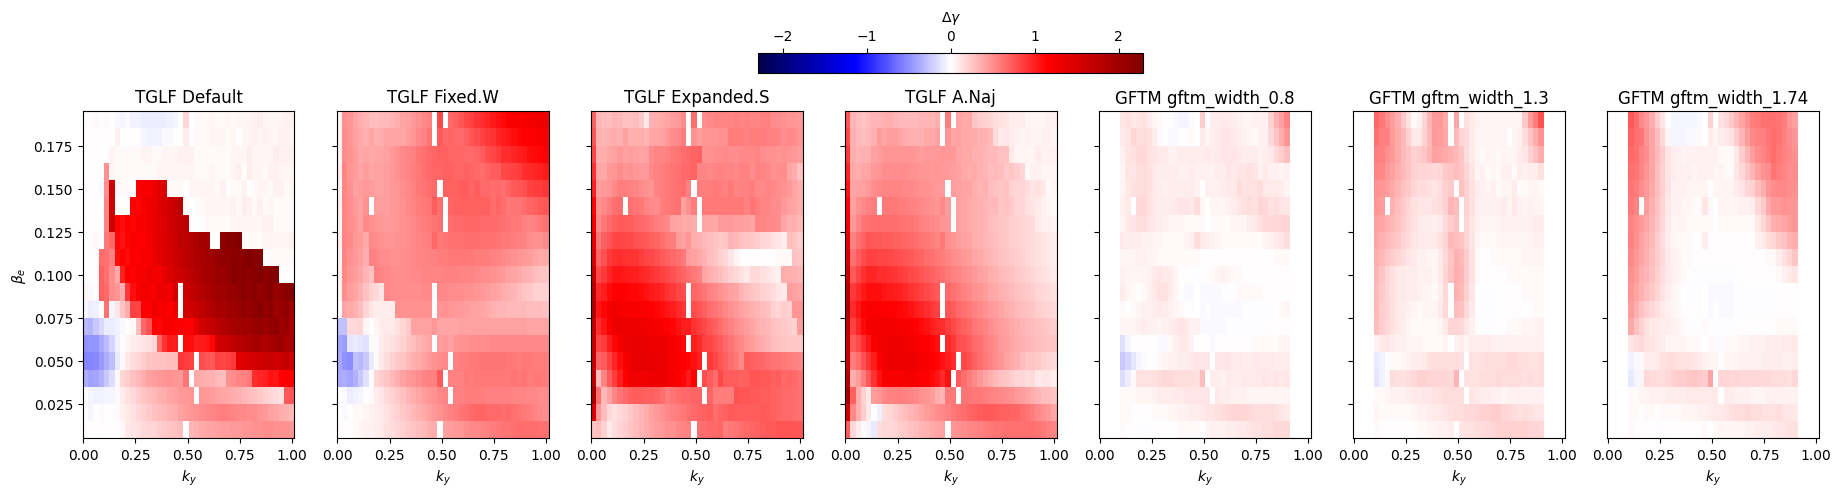

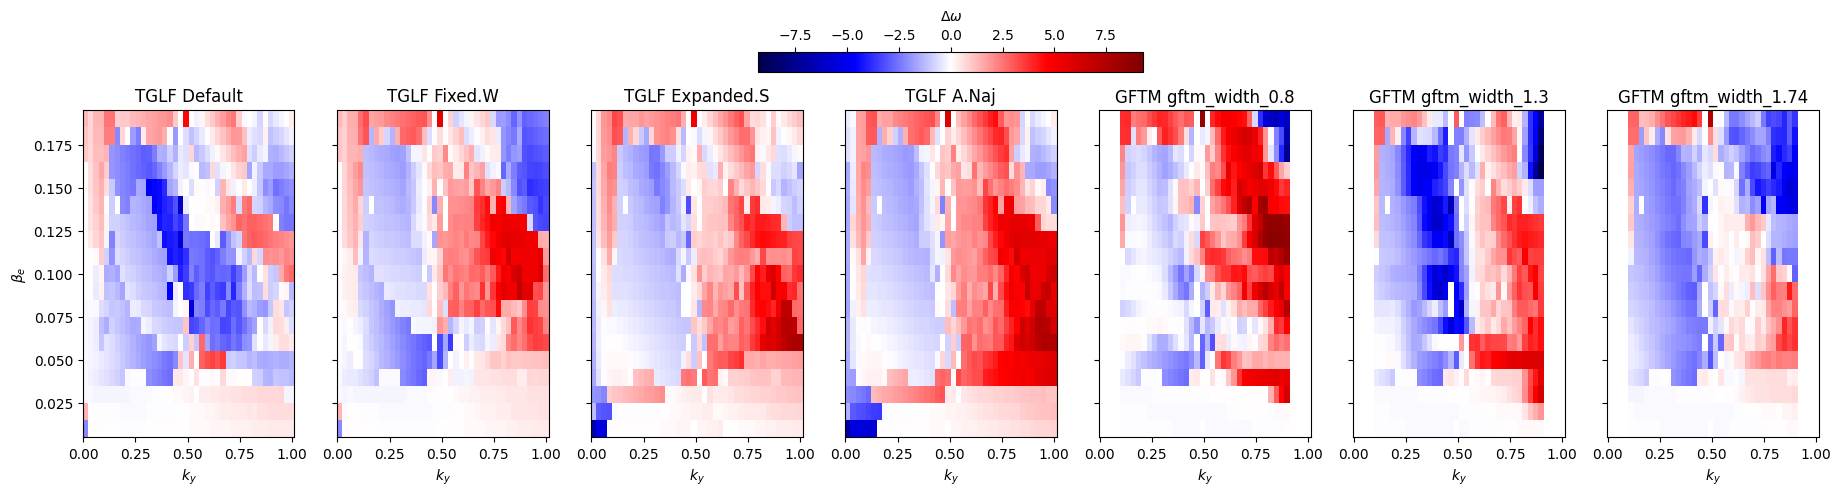

In [38]:
project, case = "scan_beta", "M1_A1_NE"

gs2 = project_dict[project][case].gk_output

tglfs = {
    version: tglf_project_dict[project][case][version].gk_output
    for version in tglf_versions
}

gftms = {
    version: gftm_project_dict[project][case][version].gk_output
    for version in gftm_versions
}

for field in ["growth_rate", "mode_frequency"]:
    name = f"Absolute Error Colourmap {field} For {case}"
    location = f"../Plots/{project}/{case}/{name}.png"

    plot_field_difference(
        gs2_output=gs2,
        tglf_outputs=tglfs,
        gftm_outputs=gftms,
        field=field,
        metric="absolute",
        scan_param="beta",
        savefig=location,
    )

In [40]:
# ======================================================================
# Scalar error metrics for GS2-vs-TGLF and GS2-vs-GFTM comparisons.
#
# Reduces each (ky, scan) difference grid — the same grids drawn by the
# colourmap cell — to scalar metrics per:
#
#     project / case / model / version / field
#
# Requires:
#   - _difference_grid
#   - project_dict
#   - tglf_project_dict
#   - gftm_project_dict
#   - tglf_versions
#   - gftm_versions
#
# Optional:
#   - name_dict, used to give GFTM versions clean display labels.
# ======================================================================

import numpy as np
import pandas as pd


try:
    _difference_grid
except NameError as exc:
    raise NameError(
        "Run the absolute-error colourmap cell first — "
        "_difference_grid is defined there."
    ) from exc


FIELDS = ["growth_rate", "mode_frequency"]

# GS2 convergence filter: drop points whose eigenvalue is poorly converged.
# The same mask is applied to growth rate and mode frequency because the
# tolerance describes the quality of the complete linear eigenvalue solve.
APPLY_TOL_MASK = True
TOL_FIELD = "growth_rate_tolerance"
TOL_MAX = 0.3


# Clean display names for GFTM. This falls back to the raw version name if
# name_dict has not been defined.
try:
    GFTM_NAME_DICT = name_dict
except NameError:
    GFTM_NAME_DICT = {
        "gftm_width_0.8": "Width 0.8",
        "gftm_width_1.3": "Width 1.3",
        "gftm_width_1.74": "Width 1.74",
    }


def _keep_mask(gs2_output, scan_param):
    """Return a Boolean mask identifying sufficiently converged GS2 points."""

    if not APPLY_TOL_MASK:
        return None

    if TOL_FIELD not in gs2_output:
        return None

    tol = gs2_output[TOL_FIELD]

    try:
        tol = tol.transpose("ky", scan_param)
    except ValueError as exc:
        print(
            f"Could not transpose {TOL_FIELD} using "
            f"('ky', '{scan_param}'): {exc}"
        )
        return None

    return np.asarray(tol.values) < TOL_MAX


def _metrics(diff, gs2_vals, keep=None):
    """
    Calculate scalar error metrics.

    Parameters
    ----------
    diff
        Signed model-minus-GS2 difference grid.
    gs2_vals
        Corresponding GS2 values.
    keep
        Optional Boolean convergence mask.

    Returns
    -------
    dict
        N, MAE, RMSE, nRMSE, bias and maximum absolute error.
    """

    d = np.asarray(diff, dtype=float)
    g = np.abs(np.asarray(gs2_vals, dtype=float))

    if d.shape != g.shape:
        raise ValueError(
            f"Difference and GS2 grids have different shapes: "
            f"{d.shape} and {g.shape}"
        )

    if keep is not None:
        keep = np.asarray(keep, dtype=bool)

        if keep.shape != d.shape:
            raise ValueError(
                f"Convergence mask shape {keep.shape} does not match "
                f"difference-grid shape {d.shape}"
            )

        d = d[keep]
        g = g[keep]

    d = d.ravel()
    g = g.ravel()

    # Both the difference and GS2 reference value must be finite.
    ok = np.isfinite(d) & np.isfinite(g)
    d = d[ok]
    g = g[ok]

    if d.size == 0:
        return {
            "N": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "nRMSE": np.nan,
            "bias": np.nan,
            "max_abs": np.nan,
        }

    rmse = np.sqrt(np.mean(d**2))
    peak = np.max(g)

    return {
        "N": int(d.size),
        "MAE": float(np.mean(np.abs(d))),
        "RMSE": float(rmse),
        "nRMSE": float(rmse / peak) if peak > 0 else np.nan,
        "bias": float(np.mean(d)),
        "max_abs": float(np.max(np.abs(d))),
    }


def _append_model_metrics(
    rows,
    project,
    case,
    gs2_scan,
    model_name,
    model_scans,
    versions,
    display_names=None,
):
    """
    Calculate metrics for all available versions of one reduced model.

    Parameters
    ----------
    rows
        List to which metric rows are appended.
    project, case
        Current project and case names.
    gs2_scan
        GS2 PyroScan object.
    model_name
        Model label, for example ``"TGLF"`` or ``"GFTM"``.
    model_scans
        Dictionary mapping version names to PyroScan objects.
    versions
        Ordered list of requested versions.
    display_names
        Optional mapping from stored version names to display labels.
    """

    if display_names is None:
        display_names = {}

    for version in versions:
        if version not in model_scans:
            print(
                f"skip {project}/{case}/{model_name}/{version}: "
                "version not loaded"
            )
            continue

        display_version = display_names.get(version, version)

        for field in FIELDS:
            try:
                _, _, diff, scan_param = _difference_grid(
                    gs2_output=gs2_scan.gk_output,
                    model_output=model_scans[version].gk_output,
                    field=field,
                    metric="absolute",
                    scan_param=None,
                    mode=0,
                )

                keep = _keep_mask(
                    gs2_output=gs2_scan.gk_output,
                    scan_param=scan_param,
                )

                gs2_vals = (
                    gs2_scan.gk_output[field]
                    .transpose("ky", scan_param)
                    .values
                )

                rows.append(
                    {
                        "project": project,
                        "case": case,
                        "model": model_name,
                        "version_key": version,
                        "version": display_version,
                        "field": field,
                        "scan": scan_param,
                        **_metrics(diff, gs2_vals, keep),
                    }
                )

            except Exception as exc:
                print(
                    f"skip {project}/{case}/{model_name}/"
                    f"{version}/{field}: {exc}"
                )


rows = []

for project, case_dict in project_dict.items():
    for case, gs2_scan in case_dict.items():

        # --------------------------------------------------------------
        # TGLF
        # --------------------------------------------------------------
        tglf_scans = (
            tglf_project_dict
            .get(project, {})
            .get(case, {})
        )

        _append_model_metrics(
            rows=rows,
            project=project,
            case=case,
            gs2_scan=gs2_scan,
            model_name="TGLF",
            model_scans=tglf_scans,
            versions=tglf_versions,
        )

        # --------------------------------------------------------------
        # GFTM
        # --------------------------------------------------------------
        gftm_scans = (
            gftm_project_dict
            .get(project, {})
            .get(case, {})
        )

        _append_model_metrics(
            rows=rows,
            project=project,
            case=case,
            gs2_scan=gs2_scan,
            model_name="GFTM",
            model_scans=gftm_scans,
            versions=gftm_versions,
            display_names=GFTM_NAME_DICT,
        )


metrics_df = pd.DataFrame(rows)

if metrics_df.empty:
    raise ValueError(
        "No metrics were calculated. Check that the GS2, TGLF and GFTM "
        "project dictionaries contain matching project/case entries."
    )


# ----------------------------------------------------------------------
# Set explicit ordering
# ----------------------------------------------------------------------

tglf_display_versions = list(tglf_versions)

gftm_display_versions = [
    GFTM_NAME_DICT.get(version, version)
    for version in gftm_versions
]

all_display_versions = tglf_display_versions + gftm_display_versions

metrics_df["model"] = pd.Categorical(
    metrics_df["model"],
    categories=["TGLF", "GFTM"],
    ordered=True,
)

metrics_df["version"] = pd.Categorical(
    metrics_df["version"],
    categories=all_display_versions,
    ordered=True,
)

metrics_df = metrics_df.sort_values(
    ["project", "case", "field", "model", "version"]
).reset_index(drop=True)


# ----------------------------------------------------------------------
# Combined RMSE table
#
# Rows:
#     case / field
#
# Columns:
#     model / version
# ----------------------------------------------------------------------

rmse_table = (
    metrics_df
    .pivot_table(
        index=["case", "field"],
        columns=["model", "version"],
        values="RMSE",
        observed=True,
    )
)


# Explicitly arrange TGLF columns before GFTM columns.
ordered_columns = [
    ("TGLF", version)
    for version in tglf_display_versions
    if ("TGLF", version) in rmse_table.columns
] + [
    ("GFTM", version)
    for version in gftm_display_versions
    if ("GFTM", version) in rmse_table.columns
]

rmse_table = rmse_table.reindex(
    columns=pd.MultiIndex.from_tuples(
        ordered_columns,
        names=["model", "version"],
    )
)


# ----------------------------------------------------------------------
# Separate model tables, which may be easier to use in the paper.
# ----------------------------------------------------------------------

tglf_rmse_table = (
    metrics_df.loc[metrics_df["model"] == "TGLF"]
    .pivot_table(
        index=["case", "field"],
        columns="version",
        values="RMSE",
        observed=True,
    )
    .reindex(columns=tglf_display_versions)
)

gftm_rmse_table = (
    metrics_df.loc[metrics_df["model"] == "GFTM"]
    .pivot_table(
        index=["case", "field"],
        columns="version",
        values="RMSE",
        observed=True,
    )
    .reindex(columns=gftm_display_versions)
)


# ----------------------------------------------------------------------
# Output
# ----------------------------------------------------------------------

print(
    metrics_df.to_string(
        index=False,
        float_format=lambda value: f"{value:.4g}",
    )
)

print(
    "\nCombined RMSE by case, field, model and version:\n"
)

print(
    rmse_table.to_string(
        float_format=lambda value: f"{value:.4g}"
    )
)

print("\nTGLF RMSE by case and field:\n")

print(
    tglf_rmse_table.to_string(
        float_format=lambda value: f"{value:.4g}"
    )
)

print("\nGFTM RMSE by case and field:\n")

print(
    gftm_rmse_table.to_string(
        float_format=lambda value: f"{value:.4g}"
    )
)


# ----------------------------------------------------------------------
# LaTeX tables
#
# Requires \usepackage{booktabs}.
# The multi-index versions also generally benefit from:
#     \usepackage{multirow}
# ----------------------------------------------------------------------

print("\nCombined LaTeX table:\n")

print(
    rmse_table.to_latex(
        float_format="%.3g",
        multicolumn=True,
        multirow=True,
    )
)

print("\nTGLF LaTeX table:\n")

print(
    tglf_rmse_table.to_latex(
        float_format="%.3g",
        multicolumn=True,
        multirow=True,
    )
)

print("\nGFTM LaTeX table:\n")

print(
    gftm_rmse_table.to_latex(
        float_format="%.3g",
        multicolumn=True,
        multirow=True,
    )
)

/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/scipy/interpolate/_polyint.py:126: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  yi = np.asarray(yi)
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/scipy/interpolate/_interpolate.py:312: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  y = array(y, copy=self.copy)
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


  project     case model     version_key    version          field scan   N     MAE    RMSE  nRMSE       bias  max_abs
scan_beta M1_A1_NE  TGLF         Default    Default    growth_rate beta 463  0.9033   1.189  2.127     0.8607    2.294
scan_beta M1_A1_NE  TGLF         Fixed.W    Fixed.W    growth_rate beta 463  0.4243  0.4597 0.8222      0.397    0.717
scan_beta M1_A1_NE  TGLF      Expanded.S Expanded.S    growth_rate beta 463  0.6483  0.7416  1.326     0.6483    1.895
scan_beta M1_A1_NE  TGLF           A.Naj      A.Naj    growth_rate beta 463  0.6073  0.6977  1.248     0.6064     1.98
scan_beta M1_A1_NE  GFTM  gftm_width_0.8  Width 0.8    growth_rate beta 398 0.05489  0.0716 0.1559    0.04484   0.2467
scan_beta M1_A1_NE  GFTM  gftm_width_1.3  Width 1.3    growth_rate beta 398  0.1115  0.1464  0.319     0.1095   0.5052
scan_beta M1_A1_NE  GFTM gftm_width_1.74 Width 1.74    growth_rate beta 398 0.08298  0.1323 0.2881    0.07797   0.5377
scan_beta M1_A1_NE  TGLF         Default    Defa

/tmp/ipykernel_83571/3686667262.py:303: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  metrics_df["model"] = pd.Categorical(
/tmp/ipykernel_83571/3686667262.py:309: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
Y